# 🧠 1. Notebook Sections (TDSP Style)

## 🟦 1. Business Understanding

Time Series Forecasting (DSO3)

Objective
Predict future:
- Latency
- Throughput

Goal
Anticipate SLA violations before they happen.

KPI
- Mean Absolute Error (MAE)

## 🟦 2. Data Understanding

In [24]:
import pandas as pd

df = pd.read_csv("C:\\Users\\user\\OneDrive - ESPRIT\\Bureau\\Predigo-DS\\Esprit-PI-4DS9-2526-QoSentry\\data\\network_qoe_latest(in).csv")
#df = pd.read_csv("../../data/network_qoe_latest(in).csv")
df.head()

df.info()
df.describe()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 93276 entries, 0 to 93275
Data columns (total 33 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   run_id                  93276 non-null  object 
 1   timestamp               93276 non-null  float64
 2   datetime                93276 non-null  object 
 3   segment                 93276 non-null  object 
 4   switch_id               93276 non-null  int64  
 5   port_no                 93276 non-null  int64  
 6   mos_voice               93276 non-null  float64
 7   e2e_delay_ms            93276 non-null  float64
 8   plr                     93276 non-null  float64
 9   jitter_ms               93276 non-null  float64
 10  cdr_flag                93276 non-null  int64  
 11  call_setup_time_ms      93276 non-null  float64
 12  buffering_ratio         93276 non-null  float64
 13  rebuffering_freq        93276 non-null  float64
 14  rebuffering_count       93276 non-null

,timestamp,switch_id,port_no,mos_voice,e2e_delay_ms,plr,jitter_ms,cdr_flag,call_setup_time_ms,buffering_ratio,...,availability,rx_bytes,tx_bytes,rx_packets,tx_packets,rx_dropped,tx_dropped,dataplane_latency_ms,ctrl_plane_rtt_ms,flow_count
count,9.327600e+04,93276.0,93276.00000,93276.000000,93276.000000,93276.000000,93276.000000,93276.000000,93276.000000,93276.000000,...,93276.000000,9.327600e+04,9.327600e+04,9.327600e+04,9.327600e+04,93276.0,93276.0,66509.000000,93276.000000,93276.000000
mean,1.774461e+09,1.0,2.50000,3.549245,29.194200,0.101875,2.809204,0.186865,866.909422,0.942945,...,0.868106,5.680891e+08,4.844745e+08,1.264209e+06,1.080825e+06,0.0,0.0,37.840748,7.685224,5.128222
std,1.416195e+04,0.0,1.11804,1.209980,39.786993,0.225927,3.087028,0.389805,1659.571116,0.110264,...,0.271283,6.554732e+08,3.541685e+08,1.192834e+06,8.502812e+05,0.0,0.0,44.245440,2.034675,2.464236
min,1.774436e+09,1.0,1.00000,1.000000,3.753000,0.000000,0.000000,0.000000,237.500000,0.000000,...,0.000000,0.000000e+00,9.800000e+01,0.000000e+00,1.000000e+00,0.0,0.0,5.413000,3.753000,0.000000
25%,1.774448e+09,1.0,1.75000,2.967000,8.818000,0.000000,1.145000,0.000000,295.700000,0.901800,...,0.951400,4.876517e+07,1.771404e+08,2.756290e+05,4.657062e+05,0.0,0.0,10.239000,6.356000,4.000000
50%,1.774461e+09,1.0,2.50000,4.190000,10.913000,0.008396,1.988100,0.000000,375.800000,0.973800,...,0.991600,2.641800e+08,3.940902e+08,8.397595e+05,8.388740e+05,0.0,0.0,21.775000,7.414000,6.000000
75%,1.774473e+09,1.0,3.25000,4.398000,27.071000,0.048606,3.020000,0.000000,721.000000,0.995200,...,1.000000,9.885544e+08,7.538861e+08,2.089334e+06,1.543603e+06,0.0,0.0,36.596000,8.745000,8.000000
max,1.774485e+09,1.0,4.00000,4.400000,241.608000,1.000000,56.448000,1.000000,10000.000000,1.000000,...,1.000000,2.563804e+09,1.278238e+09,4.189148e+06,3.550140e+06,0.0,0.0,241.608000,65.792000,48.000000


📊 Plot time series

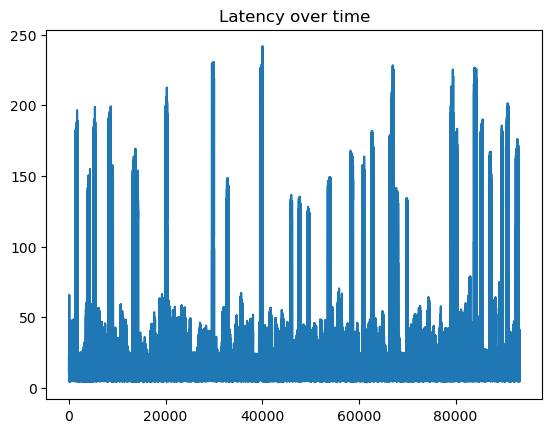

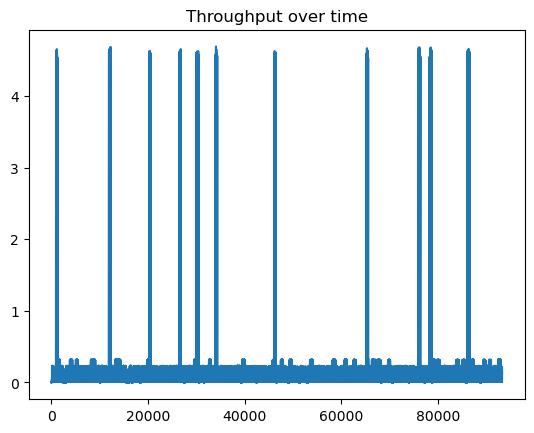

In [25]:
import matplotlib.pyplot as plt

plt.figure()
plt.plot(df["e2e_delay_ms"])
plt.title("Latency over time")
plt.show()

plt.figure()
plt.plot(df["throughput_mbps"])
plt.title("Throughput over time")
plt.show()

## 3. Data Preparation

🔹 Select features

In [ ]:
df_ts = df[["timestamp", "e2e_delay_ms", "throughput_mbps"]].copy()

df_ts["timestamp"] = pd.to_datetime(df_ts["timestamp"])

df_ts = df_ts.sort_values("timestamp")#LSTM models require the data to be sorted by time
                                      #LSTM learns temporal dependencies, so the order of the data matters
df_ts.set_index("timestamp", inplace=True)



🔹 Scaling

In [27]:
from sklearn.preprocessing import MinMaxScaler


train_size = int(0.8 * len(df_ts))
train_data = df_ts[:train_size]
test_data = df_ts[train_size:]

scaler = MinMaxScaler()
train_scaled = scaler.fit_transform(train_data)
test_scaled = scaler.transform(test_data)

scaled_data = np.vstack([train_scaled, test_scaled])


🟦 4. Create Sequences (VERY IMPORTANT)

In [ ]:
import numpy as np

def create_sequences(data, window_size=60):
    #The model will look at the past 60 time steps to predict the next one.
    X, y = [], []
    
    for i in range(len(data) - window_size):
        X.append(data[i:i+window_size])#past sequence
        y.append(data[i+window_size])#next time step to predict
    
    return np.array(X), np.array(y)

X, y = create_sequences(scaled_data, 60)

print(X.shape, y.shape)

(93216, 60, 2) (93216, 2)


🟦 5. Train/Test Split (Time-based)

In [29]:
split = int(0.8 * len(X))

X_train, X_test = X[:split], X[split:]
y_train, y_test = y[:split], y[split:]

🟦 6. Build LSTM Model

In [ ]:
import torch
import torch.nn as nn

class LSTMRegressor(nn.Module):
    def __init__(self, input_size, hidden_size, output_size):
        super().__init__()
        self.lstm = nn.LSTM(input_size, hidden_size, batch_first=True,dropout=0.2)
        #LSTM is designed for time series data .
        self.fc = nn.Sequential(
            nn.Linear(hidden_size, 32),
            nn.ReLU(),
            nn.Linear(32, output_size)
        )

    def forward(self, x):
        out, _ = self.lstm(x)
        out = out[:, -1, :]  # last timestep
        return self.fc(out)

model = LSTMRegressor(input_size=X.shape[2], hidden_size=64, output_size=y.shape[1])
print(model)

LSTMRegressor(
  (lstm): LSTM(2, 64, batch_first=True)
  (fc): Sequential(
    (0): Linear(in_features=64, out_features=32, bias=True)
    (1): ReLU()
    (2): Linear(in_features=32, out_features=2, bias=True)
  )
)


🟦 7. Train Model

In [ ]:
from torch.utils.data import DataLoader, TensorDataset

# Tensors
X_train_t = torch.tensor(X_train, dtype=torch.float32)
y_train_t = torch.tensor(y_train, dtype=torch.float32)
X_test_t = torch.tensor(X_test, dtype=torch.float32)
y_test_t = torch.tensor(y_test, dtype=torch.float32)

# DataLoader
train_loader = DataLoader(
    TensorDataset(X_train_t, y_train_t),
    batch_size=32,
    shuffle=False
)

# Training setup
criterion = nn.L1Loss()#MAE Loss    
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)

# Training loop
history = []
model.train()

for epoch in range(20):  # ⬅️ increased epochs
    total_loss = 0

    for xb, yb in train_loader:
        optimizer.zero_grad()
        preds = model(xb)
        loss = criterion(preds, yb)
        loss.backward()
        optimizer.step()

        total_loss += loss.item()

    epoch_loss = total_loss / len(train_loader)
    history.append(epoch_loss)
    print(f"Epoch {epoch+1}/20 - Loss: {epoch_loss:.4f}")

Epoch 1/20 - Loss: 0.0504
Epoch 2/20 - Loss: 0.0421
Epoch 3/20 - Loss: 0.0400
Epoch 4/20 - Loss: 0.0373
Epoch 5/20 - Loss: 0.0345
Epoch 6/20 - Loss: 0.0316
Epoch 7/20 - Loss: 0.0287
Epoch 8/20 - Loss: 0.0264
Epoch 9/20 - Loss: 0.0247
Epoch 10/20 - Loss: 0.0236
Epoch 11/20 - Loss: 0.0226
Epoch 12/20 - Loss: 0.0218
Epoch 13/20 - Loss: 0.0207
Epoch 14/20 - Loss: 0.0198
Epoch 15/20 - Loss: 0.0192
Epoch 16/20 - Loss: 0.0188
Epoch 17/20 - Loss: 0.0184
Epoch 18/20 - Loss: 0.0177
Epoch 19/20 - Loss: 0.0177
Epoch 20/20 - Loss: 0.0173


🟦 8. Evaluation

In [32]:
from sklearn.metrics import mean_absolute_error

model.eval()
with torch.no_grad():
    y_pred = model(X_test_t).numpy()

# 🔥 Inverse scaling (IMPORTANT)
y_test_inv = scaler.inverse_transform(y_test)
y_pred_inv = scaler.inverse_transform(y_pred)

# Metrics per feature (better insight)
print("Latency MAE:", mean_absolute_error(y_test_inv[:, 0], y_pred_inv[:, 0]))
print("Throughput MAE:", mean_absolute_error(y_test_inv[:, 1], y_pred_inv[:, 1]))

Latency MAE: 7.159169498655669
Throughput MAE: 0.0833340697485733
